# M3 — Basis Risk: When the Index Isn’t Your Price

**Decision:** What happens when the index hedge pays correctly, but the price we actually pay moves differently? Allow 10–15 minutes; start with [M2](M2_forwards_and_swaps.ipynb).

Continue M2's buyer: purchase and hedge **Q = 7,200 GPU-hours** during future month 12 at hedge fixed price **K = USD 5/GPU-hour**. The supplier charges actual average price **S**; the hedge references monthly average index **I**. Both cash payments occur at the end of month 12 by hypothetical agreement, not market convention. Counterparties perform; initially ignore fees, collateral and financing.

All numbers are **hypothetical**. Our one contract difference is **region**: the supplier delivers in Region X; the index covers a broader geography. Hold equipment and service terms constant. A regional spread may widen, narrow or reverse.

Use the repository's [existing environment and editable package installation](../README.md#run-locally). Select its Python kernel. An isolated uploaded notebook does not include `liquid_compute`; editable cells below are the widget fallback.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    basis_budget_series,
    explore_basis_budget,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.hedging import (
    basis_budget_summary,
    benchmark_basis_deviations_usd,
    forward_settlements_usd,
)

# Editable hypothetical assumptions; prices are USD/GPU-hour.
gpu_hours = 7_200.0
strike = 5.0
settlement_index = 7.0
realized_basis = 0.5
budget_basis = 0.5

# Recap: S = I produces M2's perfect price hedge.
perfect_bill = gpu_hours * settlement_index
perfect_receipt = gpu_hours * (settlement_index - strike)
perfect_cost = perfect_bill - perfect_receipt
settlement = forward_settlements_usd(
    benchmark_usd_per_gpu_hour=[settlement_index],
    strike_usd_per_gpu_hour=strike,
    hedge_gpu_hours=[gpu_hours],
    settlement_months=[12],
    side="buyer",
)
print(
    f"Perfect match: bill USD {perfect_bill:,.0f}, hedge receipt "
    f"USD {settlement[0].amount_usd:,.0f}, net USD {perfect_cost:,.0f}"
)

Perfect match: bill USD 50,400, hedge receipt USD 14,400, net USD 36,000


The matching-price case costs **USD 36,000** after a **USD 14,400** hedge receipt. Financial settlement buys no capacity; the supplier purchase remains separate.

## A known spread can be budgeted

Our sign convention is **basis b = S − I**, in USD/GPU-hour. Positive means the supplier is dearer; negative means cheaper. Terminology can differ between markets. [CME's grain lesson](https://www.cmegroup.com/education/courses/introduction-to-grains-and-oilseeds/learn-about-basis-grains) uses cash minus futures; that is a commodity analogy, whereas our reference is a compute settlement index.

$$\text{buyer hedge receipt}=Q(I-K)$$
$$\text{net rental cost}=QS-Q(I-K)=Q(K+b)$$

Assume a **budget basis b₀ = USD 0.50/GPU-hour**. This is a planning assumption, not automatically today's observed basis or a guaranteed future spread.

$$\text{budgeted hedged cost}=Q(K+b_0)$$
$$\text{cost deviation from budget}=Q(b-b_0)$$

First calculate directly, then call the reusable summary.

In [3]:
actual_price = settlement_index + realized_basis
basis = actual_price - settlement_index
supplier_payment = gpu_hours * actual_price
hedge_receipt = gpu_hours * (settlement_index - strike)
net_cost = supplier_payment - hedge_receipt
budgeted_cost = gpu_hours * (strike + budget_basis)
budget_deviation = gpu_hours * (basis - budget_basis)

baseline = basis_budget_summary(
    actual_usd_per_gpu_hour=actual_price,
    benchmark_usd_per_gpu_hour=settlement_index,
    strike_usd_per_gpu_hour=strike,
    gpu_hours=gpu_hours,
    budget_basis_usd_per_gpu_hour=budget_basis,
)
show_finance_table(
    ["Calculation", "Direct USD", "Reusable result USD"],
    [
        ["Supplier payment", supplier_payment, baseline.unhedged_cost_usd],
        ["Signed hedge receipt", hedge_receipt, baseline.hedge_receipt_usd],
        ["Net cost", net_cost, baseline.net_cost_usd],
        ["Budgeted hedged cost", budgeted_cost, baseline.budgeted_cost_usd],
        ["Deviation from budget", budget_deviation, baseline.budget_deviation_usd],
    ],
)

| Calculation | Direct USD | Reusable result USD |
| --- | --- | --- |
| Supplier payment | 54,000.00 | 54,000.00 |
| Signed hedge receipt | 14,400.00 | 14,400.00 |
| Net cost | 39,600.00 | 39,600.00 |
| Budgeted hedged cost | 39,600.00 | 39,600.00 |
| Deviation from budget | 0.00 | 0.00 |

The USD 54,000 supplier bill less USD 14,400 received gives **USD 39,600**. That exceeds the perfect-match cost, but equals our budget: the planned premium is not a budget surprise. A constant nonzero basis can be budgeted; uncertainty in its future value creates exposure.

## Experiment 1 — Supplier and index rise together

Compare the planning reference I = 5, S = 5.50 with I = 7, S = 7.50. Both rise by USD 2; basis remains USD 0.50. These are alternative outcomes for the same month, not a sequence of invoices. A positive receipt reduces cost; a negative receipt means the buyer pays the hedge.

In [4]:
def buyer_case(index, actual, assumed_basis=0.5, quantity=7_200.0, fixed=5.0):
    return basis_budget_summary(
        actual_usd_per_gpu_hour=actual,
        benchmark_usd_per_gpu_hour=index,
        strike_usd_per_gpu_hour=fixed,
        gpu_hours=quantity,
        budget_basis_usd_per_gpu_hour=assumed_basis,
    )


def show_cases(cases):
    show_finance_table(
        [
            "Scenario",
            "Supplier payment USD",
            "Hedge receipt USD",
            "Net cost USD",
            "Budget deviation USD",
        ],
        [
            [
                name,
                r.unhedged_cost_usd,
                r.hedge_receipt_usd,
                r.net_cost_usd,
                r.budget_deviation_usd,
            ]
            for name, r in cases.items()
        ],
    )


show_cases(
    {
        "Planning reference (I=5, S=5.50)": buyer_case(5, 5.5),
        "Rise together (I=7, S=7.50)": buyer_case(7, 7.5),
    }
)

| Scenario | Supplier payment USD | Hedge receipt USD | Net cost USD | Budget deviation USD |
| --- | --- | --- | --- | --- |
| Planning reference (I=5, S=5.50) | 39,600.00 | 0.00 | 39,600.00 | 0.00 |
| Rise together (I=7, S=7.50) | 54,000.00 | 14,400.00 | 39,600.00 | 0.00 |

The bill rises by USD 14,400, exactly offset by additional hedge receipts. Net cost remains **USD 39,600**. A broad benchmark can track the market yet leave a regional price difference.

## Experiment 2 — The regional premium widens

Keep I = 7 but raise S to 8.50: basis becomes 1.50, a USD 1 widening from budget. The hedge still pays correctly. The buyer must absorb the regional increase that its benchmark does not capture.

In [5]:
widening_cost_usd = 7_200 * (1.5 - 0.5)
print(f"Direct widening effect: USD {widening_cost_usd:,.0f}")
show_cases(
    {
        "Unchanged spread (I=7, S=7.50)": buyer_case(7, 7.5),
        "Wider spread (I=7, S=8.50)": buyer_case(7, 8.5),
    }
)

Direct widening effect: USD 7,200


| Scenario | Supplier payment USD | Hedge receipt USD | Net cost USD | Budget deviation USD |
| --- | --- | --- | --- | --- |
| Unchanged spread (I=7, S=7.50) | 54,000.00 | 14,400.00 | 39,600.00 | 0.00 |
| Wider spread (I=7, S=8.50) | 61,200.00 | 14,400.00 | 46,800.00 | 7,200.00 |

Net cost becomes **USD 46,800**, exceeding budget by **USD 7,200**. Each USD 1/GPU-hour widening adds Q dollars with matched quantities.

## Experiment 3 — Supplier falls while index rises

Relative to I = 5, S = 5.50, suppose I rises to 7 while S falls to 4.50. Basis is now **−2.50**, below the assumed +0.50. A mismatch need not hurt the buyer: narrowing basis reduces combined cost.

In [6]:
show_cases(
    {
        "Planning reference (I=5, S=5.50)": buyer_case(5, 5.5),
        "Rise together (I=7, S=7.50)": buyer_case(7, 7.5),
        "Supplier rises more (I=7, S=8.50)": buyer_case(7, 8.5),
        "Supplier falls (I=7, S=4.50)": buyer_case(7, 4.5),
    }
)

| Scenario | Supplier payment USD | Hedge receipt USD | Net cost USD | Budget deviation USD |
| --- | --- | --- | --- | --- |
| Planning reference (I=5, S=5.50) | 39,600.00 | 0.00 | 39,600.00 | 0.00 |
| Rise together (I=7, S=7.50) | 54,000.00 | 14,400.00 | 39,600.00 | 0.00 |
| Supplier rises more (I=7, S=8.50) | 61,200.00 | 14,400.00 | 46,800.00 | 7,200.00 |
| Supplier falls (I=7, S=4.50) | 32,400.00 | 14,400.00 | 18,000.00 | -21,600.00 |

The last case pays the supplier USD 32,400 and receives USD 14,400, leaving **USD 18,000 net**, or **USD 21,600 below budget**. The negative deviation is favorable to this buyer.

## Explore the remaining exposure

Change **I**, realized **b**, and assumed **b₀** independently; Q and K stay fixed. The controls compute S = I + b and reject negative physical prices. Increase I with b fixed: unhedged cost changes, hedged cost does not. Increase b: hedged cost and deviation rise. Change b₀: only the budget comparison changes.

The saved chart uses the editable assumptions above. Controls own independent inputs; editing them cannot change the worked scenarios.

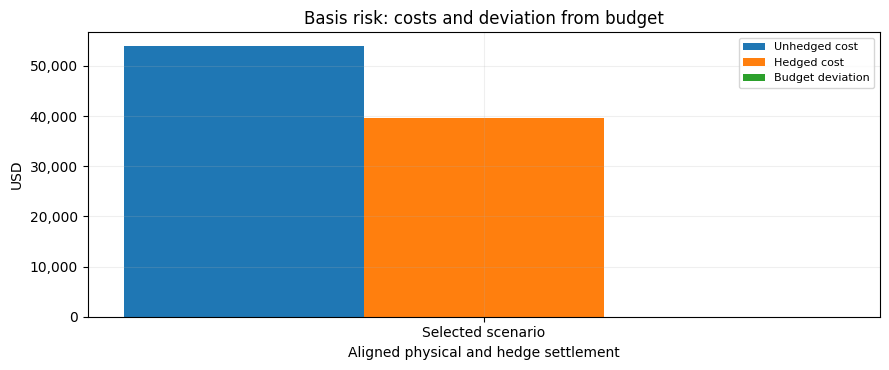

In [7]:
chart_inputs = dict(
    settlement_index_usd_per_gpu_hour=settlement_index,
    realized_basis_usd_per_gpu_hour=realized_basis,
    budget_basis_usd_per_gpu_hour=budget_basis,
    gpu_hours=gpu_hours,
    strike_usd_per_gpu_hour=strike,
)
display(
    plot_finance_series(
        basis_budget_series(**chart_inputs),
        title="Basis risk: costs and deviation from budget",
        xlabel="Aligned physical and hedge settlement",
        bar=True,
        x_tick_labels=["Selected scenario"],
    )
)
explore_basis_budget(**chart_inputs);

The default bars show USD 54,000 unhedged, USD 39,600 hedged and zero deviation. Moving the budget cannot change actual cash paid.

## Which benchmark fits this exposure?

Use the **same synthetic physical scenarios** for A and B, with explicitly assumed baseline spreads **0.50 and 0.20** respectively. Neither series describes a real provider or index history. Compare residual dollars Q[(S − I) − baseline]; different fixed hedge prices affect total budget levels, not this deviation calculation. Inspect the price table before comparing results. Missing observations must be resolved, never silently replaced with zero.

In [8]:
physical_prices = {
    "Planning reference": 5.5,
    "Rise together": 7.5,
    "Regional widening": 8.5,
    "Supplier falls": 4.5,
}
candidate_a = {
    "Planning reference": 5.0,
    "Rise together": 7.0,
    "Regional widening": 7.0,
    "Supplier falls": 7.0,
}
candidate_b = {
    "Planning reference": 5.3,
    "Rise together": 7.2,
    "Regional widening": 8.1,
    "Supplier falls": 4.4,
}
show_finance_table(
    ["Synthetic scenario", "S USD/GPU-hour", "A USD/GPU-hour", "B USD/GPU-hour"],
    [
        [name, price, candidate_a[name], candidate_b[name]]
        for name, price in physical_prices.items()
    ],
)
# Direct example, before using the aligned-scenario calculator.
print(f"Regional widening: A deviation USD {7_200 * ((8.5 - 7.0) - 0.5):,.2f}")
print(f"Regional widening: B deviation USD {7_200 * ((8.5 - 8.1) - 0.2):,.2f}")
deviations_a = benchmark_basis_deviations_usd(
    actual_prices=physical_prices,
    benchmark_prices=candidate_a,
    baseline_basis_usd_per_gpu_hour=0.5,
    gpu_hours=7_200,
)
deviations_b = benchmark_basis_deviations_usd(
    actual_prices=physical_prices,
    benchmark_prices=candidate_b,
    baseline_basis_usd_per_gpu_hour=0.2,
    gpu_hours=7_200,
)
show_finance_table(
    ["Scenario", "A deviation USD", "B deviation USD"],
    [[name, deviations_a[name], deviations_b[name]] for name in physical_prices],
)

| Synthetic scenario | S USD/GPU-hour | A USD/GPU-hour | B USD/GPU-hour |
| --- | --- | --- | --- |
| Planning reference | 5.50 | 5.00 | 5.30 |
| Rise together | 7.50 | 7.00 | 7.20 |
| Regional widening | 8.50 | 7.00 | 8.10 |
| Supplier falls | 4.50 | 7.00 | 4.40 |

Regional widening: A deviation USD 7,200.00
Regional widening: B deviation USD 1,440.00


| Scenario | A deviation USD | B deviation USD |
| --- | --- | --- |
| Planning reference | 0.00 | 0.00 |
| Rise together | 0.00 | 720.00 |
| Regional widening | 7,200.00 | 1,440.00 |
| Supplier falls | -21,600.00 | -720.00 |

A's deviations are **0, 0, +7,200, −21,600**; B's are **0, +720, +1,440, −720**. B has smaller absolute deviations in the last two scenarios; A fits the common rise exactly. There are no probabilities, so these are neither expected losses nor proof of an optimal benchmark.

Compare contract attributes too. [Ornn's price-index documentation](https://data.ornn.com/docs/price-index) describes transaction-based GPU-model prices rather than a single supplier quote. Its [forward-curve documentation](https://data.ornn.com/docs/forward-curves) distinguishes reserved term prices and implied forwards from the on-demand index. Neither establishes a hedge offer for our hypothetical contract.

A physical bill weighted by actual usage may differ from a benchmark's time average. A stable historical relationship can change. High correlation alone does not establish adequate one-for-one hedging: differently sized price moves still leave basis changes.

In [9]:
show_finance_table(
    ["Check", "Physical exposure", "Synthetic A", "Synthetic B"],
    [
        [
            "GPU specification",
            "GPU family X / configuration X",
            "Same declared spec",
            "Same declared spec",
        ],
        ["Region", "Region X", "Broad geography", "Region X"],
        ["Service terms", "Standard service", "Standard service", "Standard service"],
        [
            "Observation method",
            "Actual supplier bill",
            "Transaction basket",
            "Regional transaction basket",
        ],
        [
            "Averaging period",
            "Month 12; actual usage weights",
            "Month 12; time average",
            "Month 12; time average",
        ],
    ],
)

| Check | Physical exposure | Synthetic A | Synthetic B |
| --- | --- | --- | --- |
| GPU specification | GPU family X / configuration X | Same declared spec | Same declared spec |
| Region | Region X | Broad geography | Region X |
| Service terms | Standard service | Standard service | Standard service |
| Observation method | Actual supplier bill | Transaction basket | Regional transaction basket |
| Averaging period | Month 12; actual usage weights | Month 12; time average | Month 12; time average |

Labels guide due diligence; they do not prove price equivalence. B's closer regional match still needs an available hedge with acceptable pricing, settlement, liquidity and counterparty terms. An index is neither a supplier quote nor a guarantee of capacity.

**Takeaways:** Budget a stated spread, then stress changes around it. With matched quantities and dates, index movements cancel; basis changes remain. Wider basis hurts this buyer; narrower basis helps.

### References

Primary pages inspected for this revision: [CME: basis in grains](https://www.cmegroup.com/education/courses/introduction-to-grains-and-oilseeds/learn-about-basis-grains), [Ornn: price index](https://data.ornn.com/docs/price-index), [Ornn: forward curves](https://data.ornn.com/docs/forward-curves). All lesson prices and contract terms remain hypothetical.

### Next — M4: Price and quantity uncertainty

[Continue to M4](M4_price_quantity_scenarios.ipynb).

> Even if the benchmark tracks our price perfectly, what happens when we need more—or fewer—GPU-hours than we hedged?